# 15 — Coastal-Distance Word Cloud Banner

Produces **two wide banner images** (English + Vietnamese) where a single horizontal
strip represents the transition from far-inland hotels to beachfront hotels.

| Column | Band | Distance filter | Strip share |
|--------|------|----------------|-------------|
| Left   | C    | ≥ 0.5 km (inland)    | **50 %** |
| Middle | B    | 0.1–0.5 km (near)    | **30 %** |
| Right  | A    | < 0.1 km (beachfront)| **20 %** |

**Output:** `IMG/coast_wordcloud_en.png` and `IMG/coast_wordcloud_vi.png`

**Prerequisites:** checkpoints must exist (run notebook 11 first):
```
checkpoints/coast_band_A_en.pkl  coast_band_A_vi.pkl
checkpoints/coast_band_B_en.pkl  coast_band_B_vi.pkl
checkpoints/coast_band_C_en.pkl  coast_band_C_vi.pkl
```

## Section 1 — Imports & Config

In [ ]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from wordcloud import WordCloud

# ── Paths ──────────────────────────────────────────────────────────────────
CKPT_DIR = Path("../checkpoints")
IMG_DIR  = Path("../IMG")
IMG_DIR.mkdir(parents=True, exist_ok=True)

# ── Layout ─────────────────────────────────────────────────────────────────
BANDS = [
    {"id": "C", "label": "Band C\n≥ 0.5 km  (inland)",         "width": 50},
    {"id": "B", "label": "Band B\n0.1 – 0.5 km  (near coast)", "width": 30},
    {"id": "A", "label": "Band A\n< 0.1 km  (beachfront)",     "width": 20},
]

# ── Visual style ───────────────────────────────────────────────────────────
BG_COLORS = {
    "C": "#ffffff",
    "B": "#ffffff",
    "A": "#ffffff",
}
COLORMAP = {
    "C": "afmhot",
    "B": "gist_earth",
    "A": "PuBuGn",
}
TITLE_COLOR = {
    "C": "#7a4500",
    "B": "#1a5f9e",
    "A": "#aee8ff",
}

# ── Word cloud params ──────────────────────────────────────────────────────
NUM_WORDS   = 25   # top N words taken from each topic
NUM_TOPICS  = 10   # top N non-outlier topics to draw from
MAX_WORDS   = 300  # words drawn by WordCloud per panel
FIGSIZE     = (26, 7)

print("Config ready.")
print(f"IMG dir : {IMG_DIR.resolve()}")
print(f"Bands   : {[b['id'] for b in BANDS]}  widths={[b['width'] for b in BANDS]}")

Config ready.
IMG dir : C:\Users\darkn\coastal-hotel\IMG
Bands   : ['C', 'B', 'A']  widths=[50, 30, 20]


## Section 2 — Helper: Load Word Frequencies from Top 10 Topics

For each band checkpoint, the **top 10 non-outlier topics** are used.
The top 10 words from each topic are merged into a single frequency map;
words appearing in multiple topics accumulate their scores.
Underscores are replaced with spaces for clean Vietnamese compound-word display.

## Section 1b — Diagnostic: Inspect PKL Word Counts

Tells you exactly what each checkpoint returns for topic 0 across every representation layer.
Run this first to confirm how many words are available before generating the banner.

In [2]:
for lang in ["en", "vi"]:
    print(f"\n{'='*60}  {lang.upper()}")
    for band in BANDS:
        bid      = band["id"]
        pkl_path = CKPT_DIR / f"coast_band_{bid}_{lang}.pkl"
        if not pkl_path.exists():
            print(f"  Band {bid}: MISSING — {pkl_path.name}")
            continue

        with open(pkl_path, "rb") as f:
            saved = pickle.load(f)
        model = saved["model"]

        # ── get_topic(0): whatever representation_model left in topic_representations_
        via_get_topic = model.get_topic(0) or []

        # ── topic_representations_[0]: raw c-TF-IDF (same as get_topic in older BERTopic,
        #    but stays as c-TF-IDF in newer "aspects" API)
        via_repr = model.topic_representations_.get(0, [])

        # ── topic_aspects_: populated only in newer BERTopic aspects API
        aspects = getattr(model, "topic_aspects_", {})
        aspect_keys = list(aspects.keys()) if aspects else []
        aspect_counts = {k: len(aspects[k].get(0, [])) for k in aspect_keys} if aspects else {}

        print(f"  Band {bid} — {pkl_path.name}")
        print(f"    get_topic(0)          : {len(via_get_topic):>4} words  →  {[w for w,_ in via_get_topic[:8]]}")
        print(f"    topic_representations_: {len(via_repr):>4} words  →  {[w for w,_ in via_repr[:8]]}")
        if aspect_counts:
            for k, n in aspect_counts.items():
                print(f"    topic_aspects_[{k:8s}]: {n:>4} words")
        else:
            print(f"    topic_aspects_        : (empty — old BERTopic, POS may have overwritten repr)")


============================================================  EN
  Band C — coast_band_C_en.pkl
    get_topic(0)          :  100 words  →  ['hotel', 'staff', 'location', 'hanoi', 'stay', 'nice', 'clean', 'friendly']
    topic_representations_:  100 words  →  ['hotel', 'staff', 'location', 'hanoi', 'stay', 'nice', 'clean', 'friendly']
    topic_aspects_[KeyBERT ]:   10 words
    topic_aspects_[MMR     ]:   10 words
  Band B — coast_band_B_en.pkl
    get_topic(0)          :  100 words  →  ['hotel', 'staff', 'breakfast', 'clean', 'location', 'nice', 'stay', 'friendly']
    topic_representations_:  100 words  →  ['hotel', 'staff', 'breakfast', 'clean', 'location', 'nice', 'stay', 'friendly']
    topic_aspects_[KeyBERT ]:   10 words
    topic_aspects_[MMR     ]:   10 words
  Band A — coast_band_A_en.pkl
    get_topic(0)          :  100 words  →  ['nice', 'stay', 'time', 'excellent', 'amazing', 'experience', 'bad', 'lovely']
    topic_representations_:  100 words  →  ['nice', 'stay', 'time'

In [3]:
def band_word_freqs(pkl_path: Path, num_words: int = 10, num_topics: int = 10) -> dict:
    """Return {word: score} by merging top `num_words` words across top `num_topics` topics.

    BERTopic's get_topic_info() lists topics in descending size order (outlier -1 first).
    We skip -1, take the next `num_topics` rows, and pull `num_words` words from each
    Representation list.  Scores are rank-based within each topic (num_words → 1);
    words that appear in multiple topics have their scores summed.
    Underscores (Vietnamese compound tokens) are replaced with spaces.
    """
    if not pkl_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {pkl_path}")

    with open(pkl_path, "rb") as f:
        saved = pickle.load(f)

    model = saved["model"]
    info  = model.get_topic_info()

    # Drop outlier topic (-1) and take the top num_topics by size
    topics = info[info["Topic"] != -1].head(num_topics)

    if topics.empty:
        print(f"  ⚠  No non-outlier topics found in {pkl_path.name}")
        return {}

    freq: dict = {}
    for _, row in topics.iterrows():
        words = row["Representation"][:num_words]
        n = len(words)
        for rank, word in enumerate(words):
            clean = word.replace("_", " ").strip()
            if len(clean) < 2:
                continue
            score = n - rank  # highest rank → highest score
            freq[clean] = freq.get(clean, 0) + score

    if len(freq) < 10:
        print(f"  ⚠  Only {len(freq)} words in {pkl_path.name} — "
              f"check that top_n_words >= {num_words} in notebook 11")

    return freq


def make_color_func(cmap_name: str):
    """Return a WordCloud color_func that samples from a matplotlib colormap."""
    cmap = plt.get_cmap(cmap_name)

    def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        rng   = random_state if random_state is not None else np.random.RandomState()
        r, g, b, _ = cmap(rng.uniform(0.35, 0.95))
        return f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"

    return color_func


print("Helpers defined: band_word_freqs | make_color_func")

Helpers defined: band_word_freqs | make_color_func


## Section 3 — Build Banner

One figure per language. Three `GridSpec` columns with widths `[50, 30, 20]`.
Each column renders an independent `WordCloud` drawn from the merged topic frequencies.

In [4]:
def build_banner(lang: str, num_words: int = NUM_WORDS, num_topics: int = NUM_TOPICS, dpi: int = 150) -> Path:
    """Render and save the coastal-distance word cloud banner for one language."""
    lang_label = "Vietnamese" if lang == "vi" else "English"
    print(f"\n{'='*60}")
    print(f"Building banner  [{lang_label}]  (top {num_words} words × top {num_topics} topics)")

    # ── 1. Load word frequencies for each band ─────────────────────────────
    band_freqs = {}
    for band in BANDS:
        bid      = band["id"]
        pkl_path = CKPT_DIR / f"coast_band_{bid}_{lang}.pkl"
        print(f"  Loading band {bid}  ← {pkl_path.name}")
        band_freqs[bid] = band_word_freqs(pkl_path, num_words, num_topics)
        top5 = sorted(band_freqs[bid].items(), key=lambda x: -x[1])[:5]
        print(f"    top-5 : {[w for w,_ in top5]}  ({len(band_freqs[bid])} words total)")

    # ── 2. Figure layout ───────────────────────────────────────────────────
    fig = plt.figure(figsize=FIGSIZE, facecolor="white")
    width_ratios = [b["width"] for b in BANDS]
    gs = gridspec.GridSpec(
        1, len(BANDS),
        width_ratios=width_ratios,
        wspace=0.0,
        left=0.0, right=1.0, top=0.88, bottom=0.0,
    )

    # ── 3. Render one WordCloud per band column ────────────────────────────
    for col_idx, band in enumerate(BANDS):
        bid  = band["id"]
        freq = band_freqs[bid]

        col_share = width_ratios[col_idx] / sum(width_ratios)
        wc_w = int(FIGSIZE[0] * col_share * dpi)
        wc_h = int(FIGSIZE[1] * dpi * 0.82)

        wc = WordCloud(
            width=wc_w,
            height=wc_h,
            background_color=BG_COLORS[bid],
            color_func=make_color_func(COLORMAP[bid]),
            prefer_horizontal=0.80,
            max_words=MAX_WORDS,
            min_font_size=8,
            max_font_size=None,
            relative_scaling=0.55,
            collocations=False,
        ).generate_from_frequencies(freq)

        ax = fig.add_subplot(gs[col_idx])
        ax.set_facecolor(BG_COLORS[bid])
        ax.imshow(wc, interpolation="bilinear", aspect="auto")
        ax.axis("off")

        if col_idx < len(BANDS) - 1:
            ax.axvline(x=wc_w - 1, color="white", linewidth=3, alpha=0.6)

        ax.set_title(
            band["label"],
            fontsize=12, fontweight="bold",
            color=TITLE_COLOR[bid], pad=8, loc="center",
        )

    # ── 4. Title + direction annotation ───────────────────────────────────
    fig.suptitle(
        f"Hotel Review Topics by Distance to Coast  —  {lang_label}",
        fontsize=15, fontweight="bold", y=0.98, color="#222222",
    )
    fig.text(0.02, 0.93, "🌆  inland",
             fontsize=10, color="#7a4500", ha="left",  va="center", transform=fig.transFigure)
    fig.text(0.50, 0.93, "← farther from coast   ·   closer to coast →",
             fontsize=9,  color="#555555", ha="center", va="center", transform=fig.transFigure)
    fig.text(0.98, 0.93, "🏖  beachfront",
             fontsize=10, color="#aee8ff", ha="right", va="center", transform=fig.transFigure)

    # ── 5. Save ────────────────────────────────────────────────────────────
    out_path = IMG_DIR / f"coast_wordcloud_{lang}.png"
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  Saved → {out_path.resolve()}")
    plt.show()
    plt.close(fig)
    return out_path


print("build_banner() defined.")

build_banner() defined.


## Section 4 — Generate English Banner


Building banner  [English]  (top 10 words × top 10 topics)
  Loading band C  ← coast_band_C_en.pkl
    top-5 : ['staff', 'bad', 'nice', 'hotel', 'excellent excellent']  (89 words total)
  Loading band B  ← coast_band_B_en.pkl
    top-5 : ['cindy', 'service', 'noisy', 'door', 'clean']  (92 words total)
  Loading band A  ← coast_band_A_en.pkl
    top-5 : ['bad', 'nice', 'perfect', 'excellent', 'nice nice']  (42 words total)
  Saved → C:\Users\darkn\coastal-hotel\IMG\coast_wordcloud_en.png


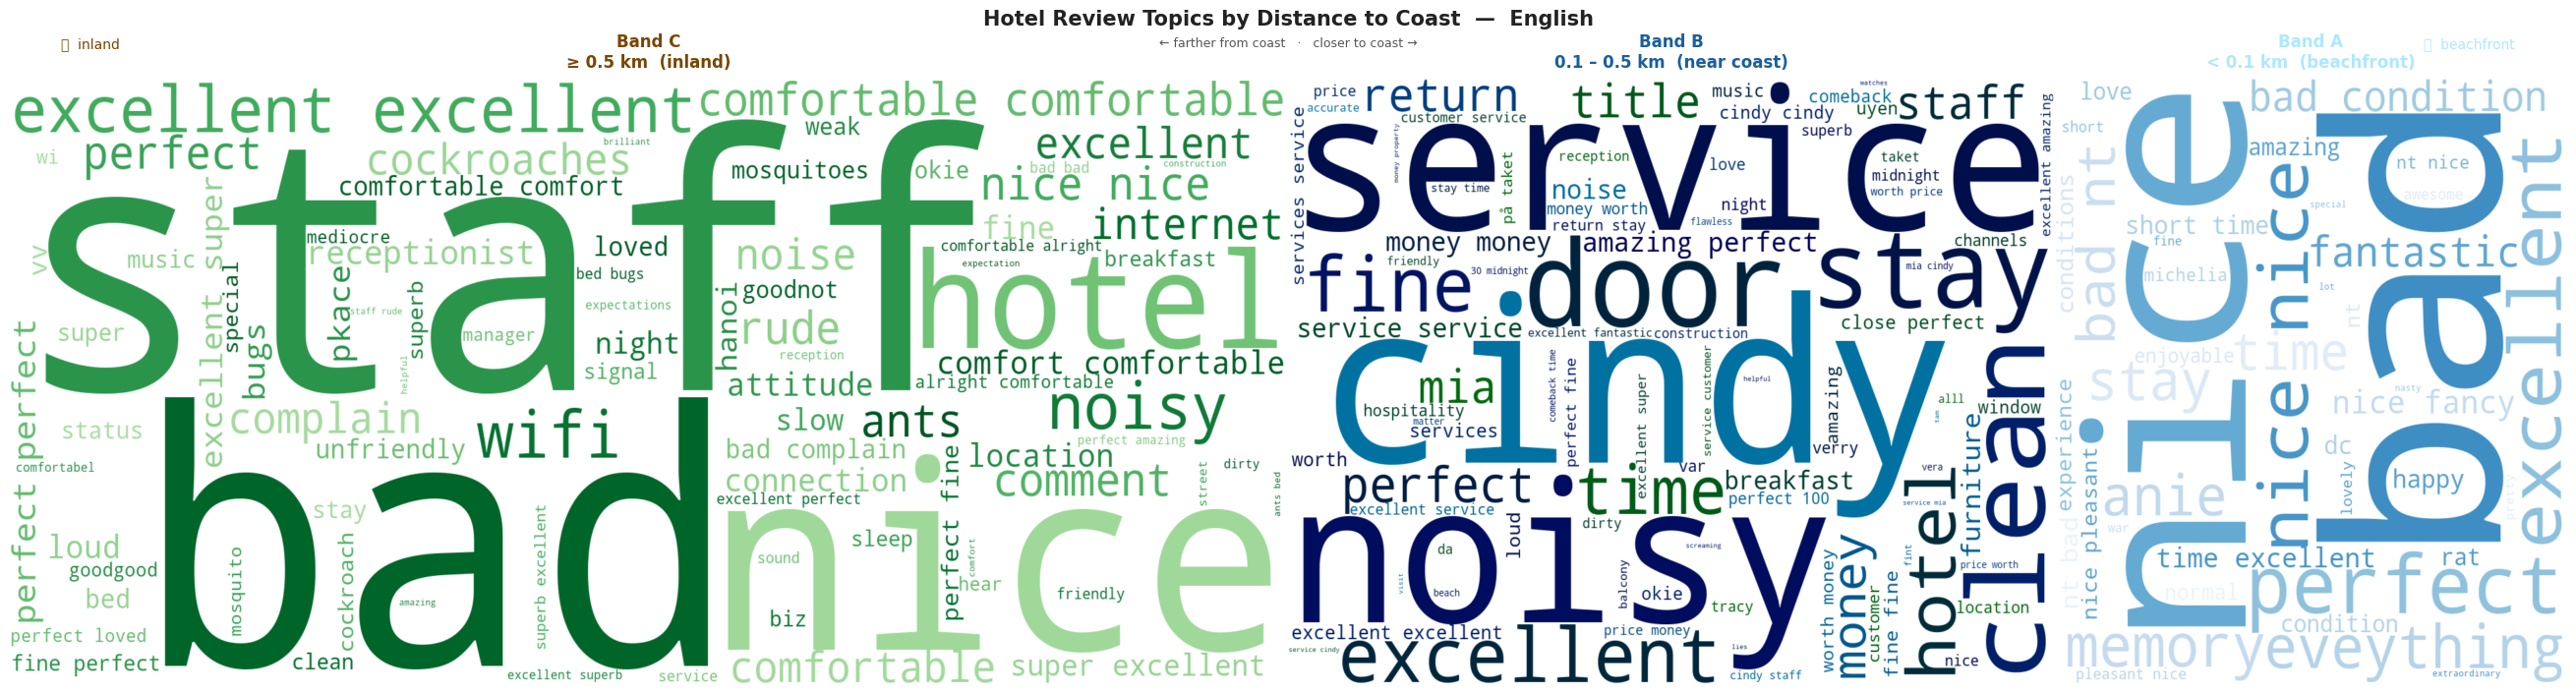


English banner → ..\IMG\coast_wordcloud_en.png


In [16]:
out_en = build_banner("en", num_words=10, num_topics=10, dpi=150)
print(f"\nEnglish banner → {out_en}")

## Section 5 — Generate Vietnamese Banner

> **Note on fonts:** Vietnamese diacritics render correctly only if matplotlib
> can find a font with full Latin-Extended coverage. If characters appear as
> boxes, install a Vietnamese-capable font and pass its path via the
> `font_path` kwarg in `WordCloud(...)`.  
> Free options: [Noto Sans](https://fonts.google.com/noto) or
> [Be Vietnam Pro](https://fonts.google.com/specimen/Be+Vietnam+Pro).


Building banner  [Vietnamese]  (top 25 words × top 10 topics)
  Loading band C  ← coast_band_C_vi.pkl
    top-5 : ['nhiệt tình', 'nhân viên', 'thân thiện', 'phục vụ', 'lễ tân']  (207 words total)
  Loading band B  ← coast_band_B_vi.pkl
    top-5 : ['khách sạn', 'tốt', 'nhân viên', 'tuyệt vời', 'phòng']  (197 words total)
  Loading band A  ← coast_band_A_vi.pkl
    top-5 : ['phòng', 'tốt', 'sáng', 'biển', 'ăn']  (112 words total)
  Saved → C:\Users\darkn\coastal-hotel\IMG\coast_wordcloud_vi.png


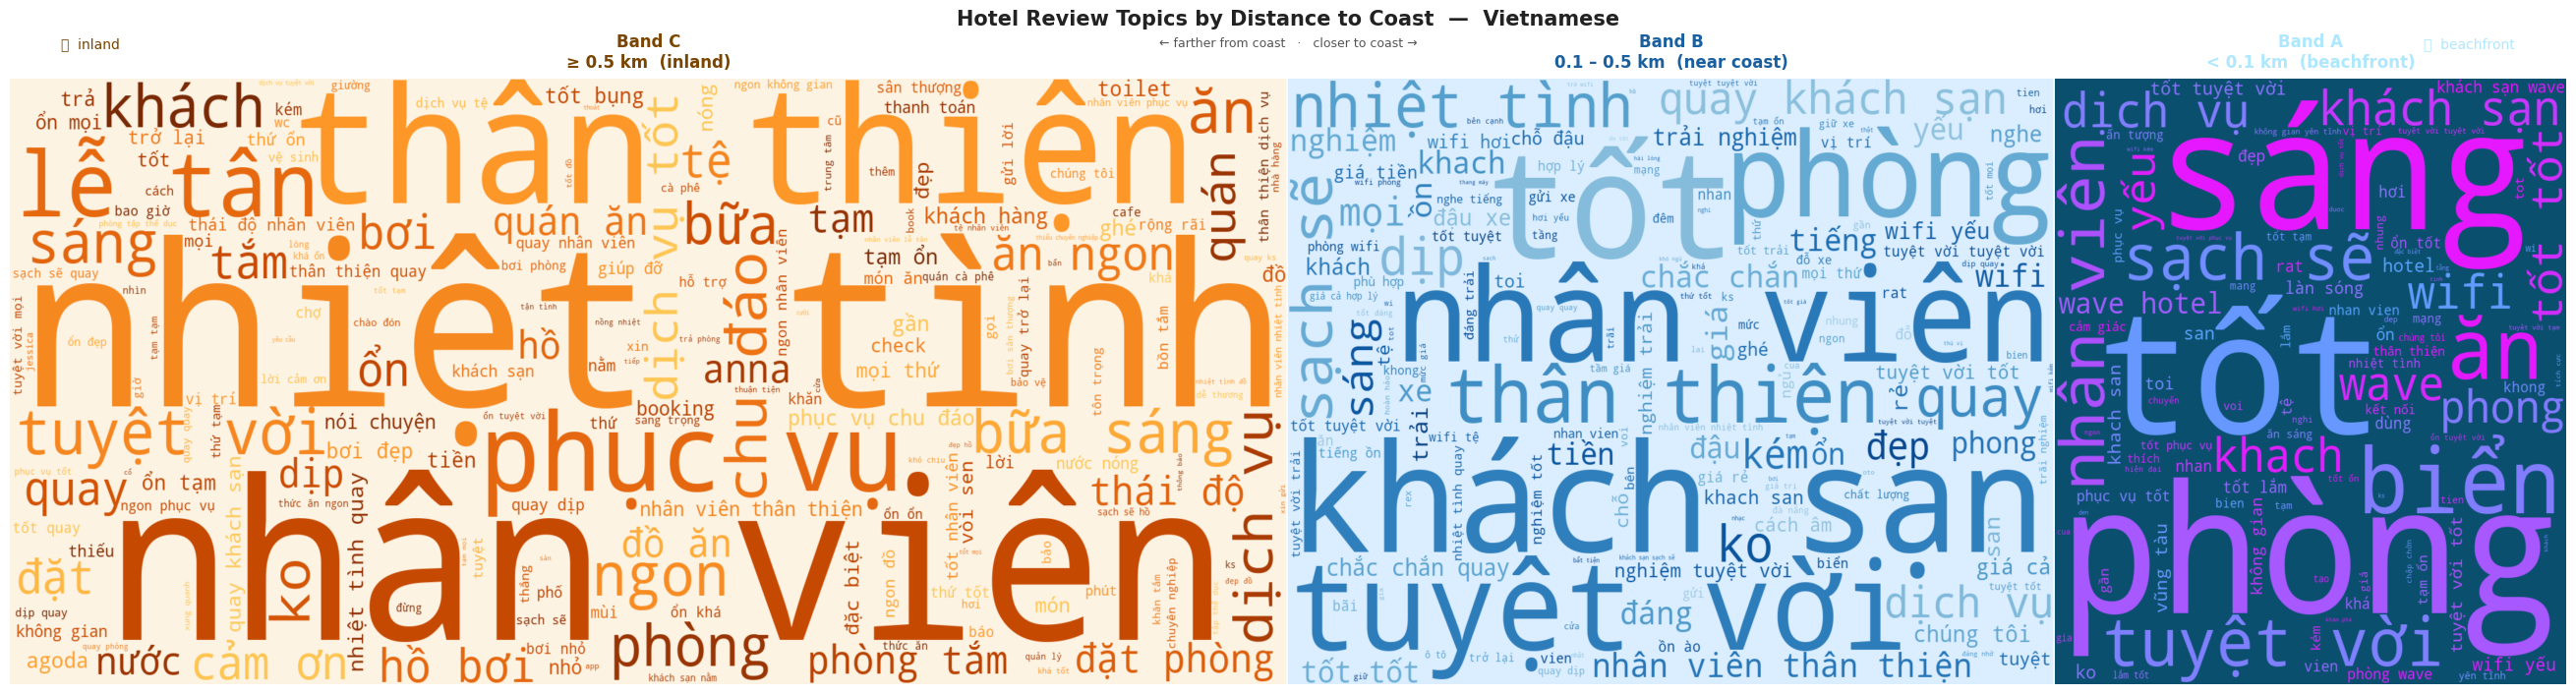


Vietnamese banner → ..\IMG\coast_wordcloud_vi.png


In [6]:
# ── Optional: point to a Vietnamese-capable font ──────────────────────────
# Uncomment and set the path if diacritics render as boxes:
# VI_FONT = r"C:\Windows\Fonts\NotoSans-Regular.ttf"
#
# Then inside build_banner() add `font_path=VI_FONT` to the WordCloud(...) call,
# or re-run build_banner with a patched version below.

out_vi = build_banner("vi")
print(f"\nVietnamese banner → {out_vi}")

## Section 6 — Side-by-Side Preview

Reload saved PNGs and display them stacked for a quick comparison.

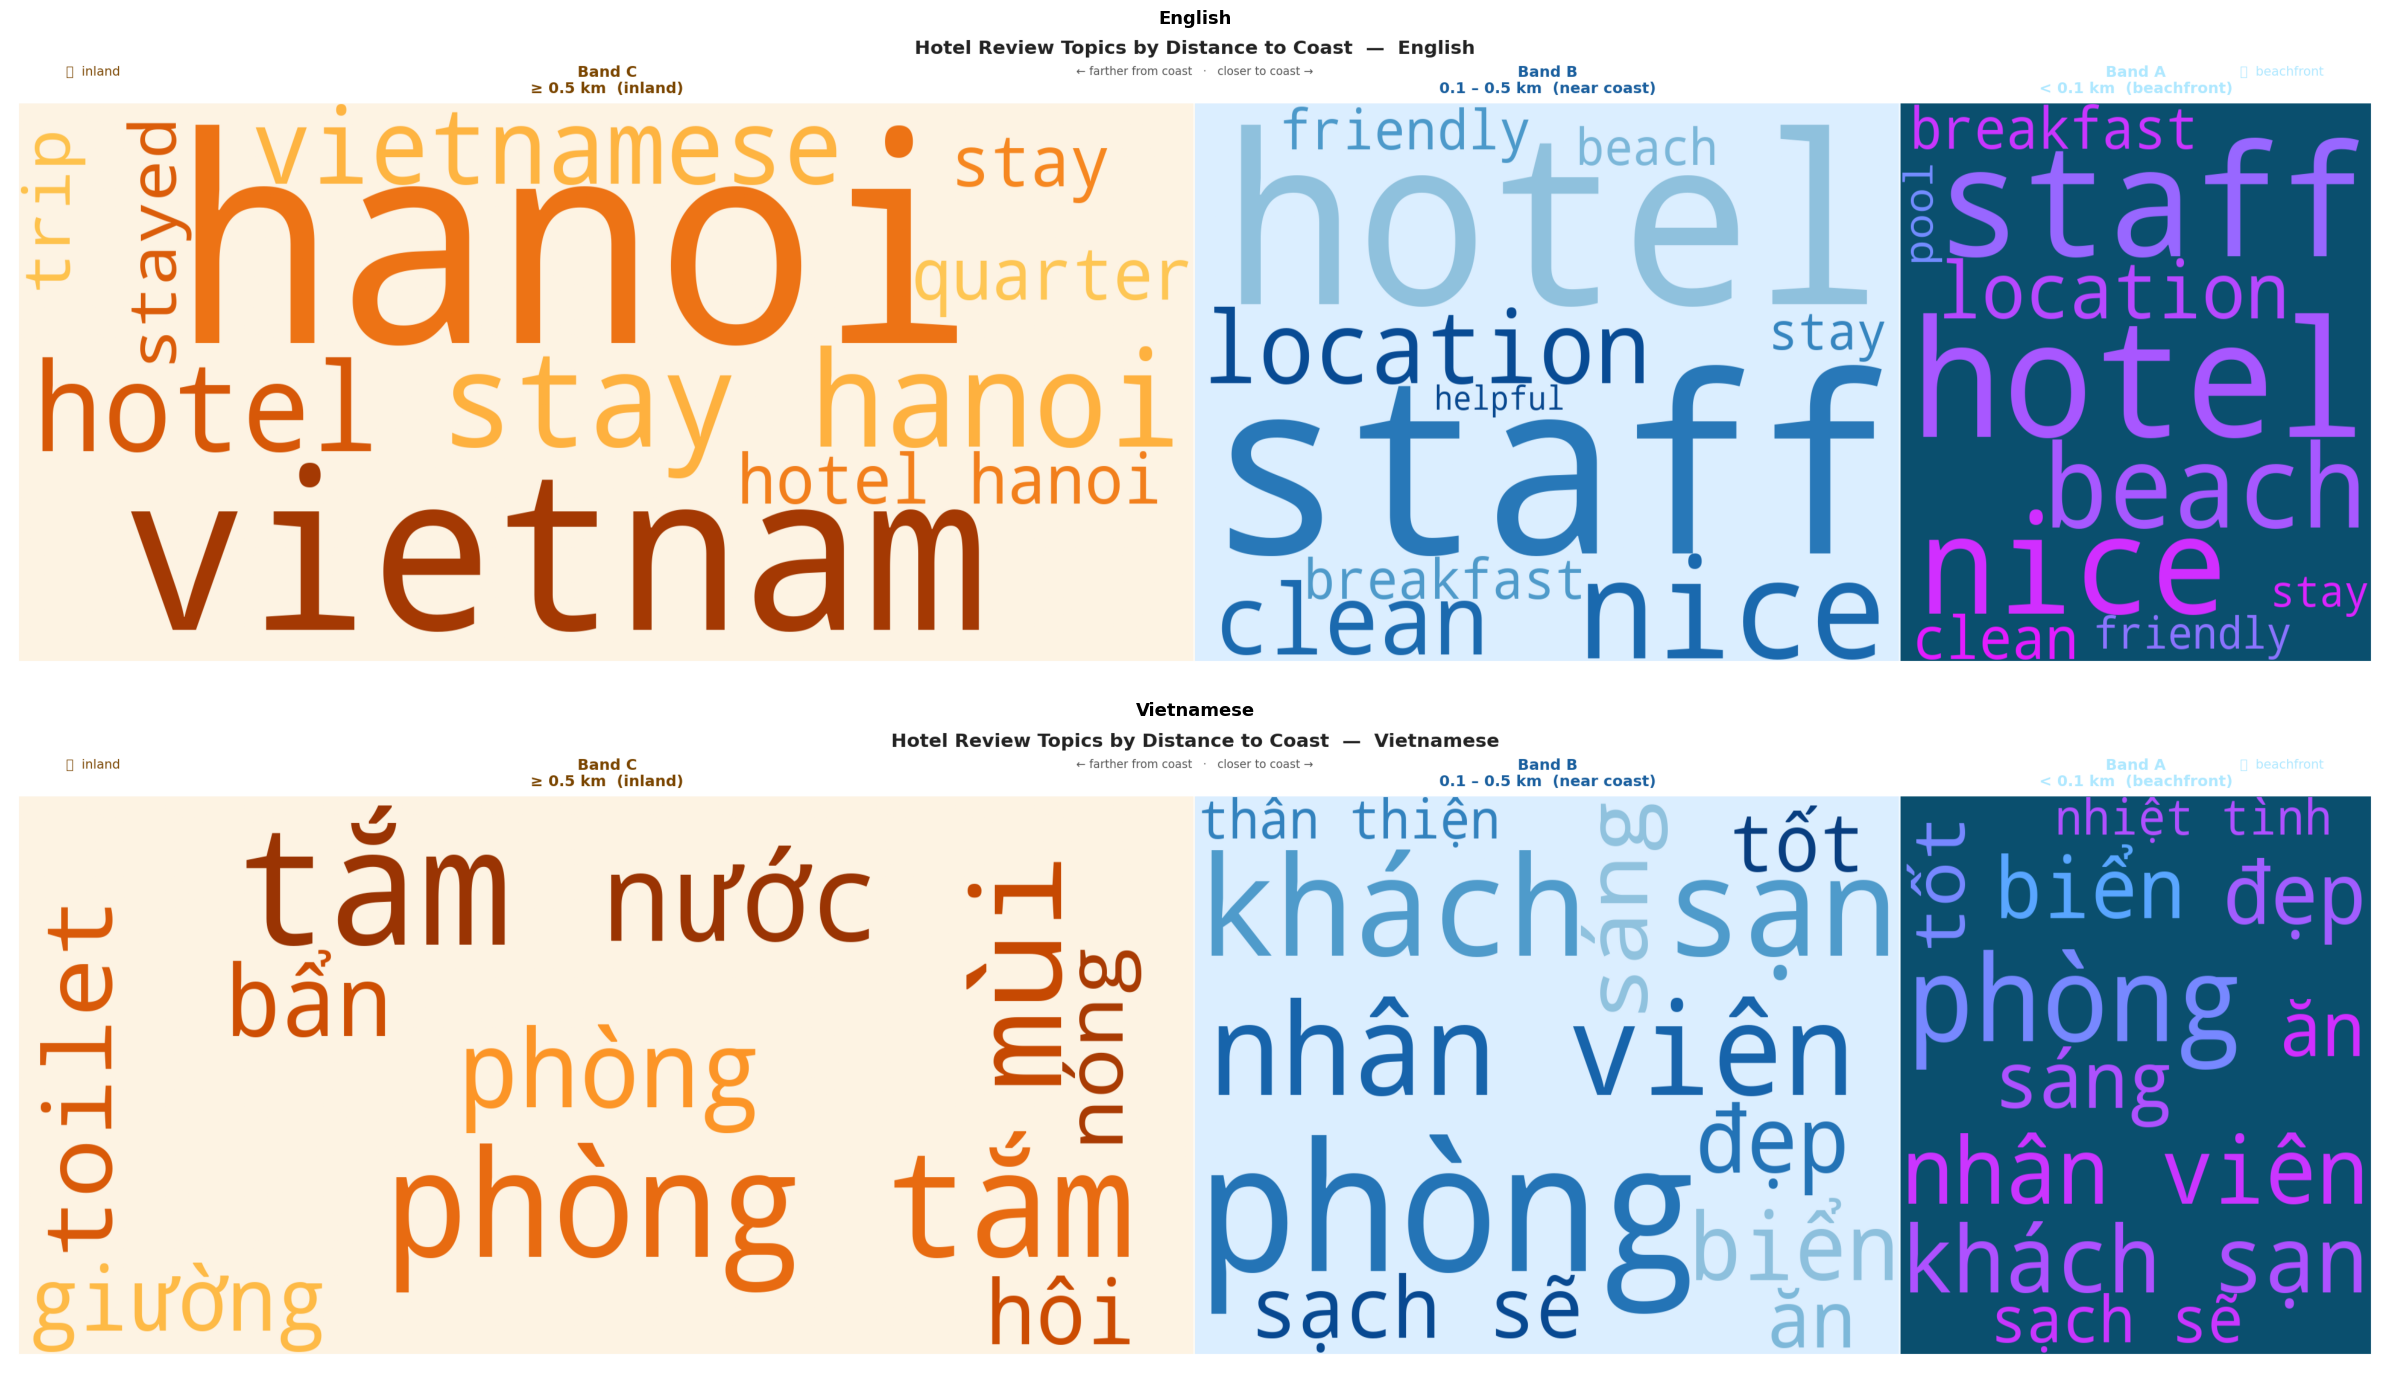

In [6]:
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 1, figsize=(24, 14))

for ax, lang, title in zip(
    axes,
    ["en", "vi"],
    ["English", "Vietnamese"],
):
    img_path = IMG_DIR / f"coast_wordcloud_{lang}.png"
    if img_path.exists():
        ax.imshow(mpimg.imread(str(img_path)))
        ax.set_title(title, fontsize=13, fontweight="bold")
    else:
        ax.text(0.5, 0.5, f"{img_path.name} not found",
                ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Section 7 — Tuning Reference

| Parameter | Default | Effect |
|-----------|---------|--------|
| `num_words` in `build_banner` | `80` | Words merged from all topics per band |
| `max_words` in `WordCloud` | `60` | Words actually drawn in each panel |
| `relative_scaling` | `0.55` | 0 = rank only; 1 = freq-proportional sizes |
| `prefer_horizontal` | `0.80` | Fraction of words laid horizontal |
| `FIGSIZE` | `(26, 7)` | Overall figure size in inches |
| `dpi` | `150` | Resolution (200 for print-quality) |
| `BAND_WIDTHS` in `BANDS` | `[50, 30, 20]` | Column proportions |

Change any of these at the top of Section 1 and re-run Sections 4–5.